Importing Libraries

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from faker import Faker
fake=Faker()



In [10]:
!pip install faker
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from faker import Faker
fake=Faker()

np.random.seed(0)
names=[fake.name() for _ in range(250)]
data={
    "Student_ID":np.random.randint(1,500,250),
    "Names":names,
    "Gender":np.random.choice(["male","female"],250),
    "Department":np.random.choice(["CSE","IT","ECE"]),
    "Year":np.random.choice(["1st","2nd","3rd"]),
    "Maths":np.random.randint(10,100,250),
    "Science":np.random.randint(10,100,250),
    "English":np.random.randint(10,100,250),
    "Attendance":np.random.randint(50,100,250),
    "Internal Marks":np.random.randint(0,25,250)
}

df=pd.DataFrame(data)
df

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 9.0 MB/s eta 0:00:00


,Student_ID,Names,Gender,Department,Year,Maths,Science,English,Attendance,Internal Marks
0,173,Bryan Farmer Jr.,female,IT,2nd,80,88,75,52,13
1,48,Kristin Garcia,female,IT,2nd,63,92,33,79,12
2,118,James Cooper,female,IT,2nd,58,79,82,57,18
3,193,Timothy Hutchinson,male,IT,2nd,69,68,10,59,0
4,324,Tracy Hoffman,male,IT,2nd,90,14,97,73,11
...,...,...,...,...,...,...,...,...,...,...
245,229,Eugene Smith,female,IT,2nd,77,47,13,51,13
246,252,Craig White,female,IT,2nd,20,98,97,51,17
247,122,Eric Harris,male,IT,2nd,67,26,39,57,22
248,327,Francis Lewis,male,IT,2nd,99,49,40,75,7


In [20]:
print("\nChecking Missing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)


Checking Missing Values:
 Student_ID        0
Names             0
Gender            0
Department        0
Year              0
Maths             0
Science           0
English           0
Attendance        0
Internal Marks    0
Total             0
Average           0
Grade             0
dtype: int64

Data Types:
 Student_ID          int64
Names              object
Gender             object
Department         object
Year               object
Maths               int64
Science             int64
English             int64
Attendance          int64
Internal Marks      int64
Total               int64
Average           float64
Grade              object
dtype: object


In [23]:
data['Total'] = data['Maths'] + data['Science'] + data['English']
data['Average'] = data['Total'] / 3
data['Total']
data['Average']

array([81.        , 62.66666667, 73.        , 49.        , 67.        ,
       36.66666667, 65.66666667, 59.        , 64.        , 65.        ,
       49.66666667, 57.        , 71.66666667, 55.66666667, 45.        ,
       57.66666667, 36.66666667, 46.33333333, 49.        , 50.66666667,
       42.33333333, 61.        , 39.        , 25.33333333, 72.66666667,
       59.33333333, 65.66666667, 73.        , 70.        , 70.33333333,
       51.33333333, 37.66666667, 35.66666667, 38.66666667, 34.33333333,
       64.33333333, 76.        , 47.66666667, 49.        , 32.66666667,
       19.33333333, 46.66666667, 55.66666667, 43.        , 65.        ,
       64.66666667, 71.        , 71.33333333, 65.33333333, 30.        ,
       39.        , 37.        , 35.33333333, 93.33333333, 44.66666667,
       69.33333333, 47.        , 29.33333333, 60.33333333, 49.        ,
       69.        , 55.        , 55.66666667, 65.33333333, 42.66666667,
       33.        , 59.66666667, 83.33333333, 52.        , 39.  

In [27]:
def grade(avg):
    if avg >= 75:
        return 'A'
    elif avg >= 60:
        return 'B'
    elif avg >= 50:
        return 'C'
    else:
        return 'Fail'

df['Grade'] = df['Average'].apply(grade)
df['Grade']

,Grade
0,A
1,B
2,B
3,Fail
4,B
...,...
245,Fail
246,B
247,Fail
248,B


In [29]:
print("\nDescriptive Statistics:\n", df.describe())


Descriptive Statistics:
        Student_ID       Maths     Science     English  Attendance  \
count  250.000000  250.000000  250.000000  250.000000  250.000000   
mean   245.964000   55.620000   52.900000   54.680000   74.908000   
std    142.269255   26.614072   26.586413   28.207094   14.379381   
min      1.000000   10.000000   10.000000   10.000000   50.000000   
25%    120.500000   33.250000   30.000000   29.000000   63.000000   
50%    250.500000   56.000000   50.000000   53.500000   77.000000   
75%    371.750000   79.750000   77.000000   81.000000   86.000000   
max    493.000000   99.000000   99.000000   99.000000   99.000000   

       Internal Marks       Total     Average  
count      250.000000  250.000000  250.000000  
mean        12.680000  163.200000   54.400000  
std          7.283254   48.793393   16.264464  
min          0.000000   42.000000   14.000000  
25%          6.000000  124.000000   41.333333  
50%         14.000000  167.000000   55.666667  
75%         18.7

In [31]:
top_students = df.sort_values(by='Average', ascending=False).head(10)
low_students = df[df['Grade'] == 'Fail']

print("\nTop 10 Students:\n", top_students[['Names', 'Average']])
print("\nFailed Students:\n", low_students[['Names', 'Average']])


Top 10 Students:
                   Names    Average
207   Kristine Mitchell  94.333333
77      John Powell Jr.  93.666667
53      Tiffany Sanders  93.333333
127     Brittney Harris  91.333333
192  Stephanie Gonzalez  89.333333
139    Patricia Leonard  87.000000
226        Mitchell Fox  86.666667
179           Chad Cole  86.333333
184        Rachel Mason  84.000000
67       Joseph Sherman  83.333333

Failed Students:
                    Names    Average
3     Timothy Hutchinson  49.000000
5           Donna Bailey  36.666667
10     Danielle Martinez  49.666667
14     William Christian  45.000000
16        Sharon Brennan  36.666667
..                   ...        ...
242  Dr. Crystal Johnson  42.333333
244   Dr. Thomas Hickman  39.333333
245         Eugene Smith  45.666667
247          Eric Harris  44.000000
249   Cassandra Hamilton  45.666667

[100 rows x 2 columns]


In [33]:
dept_perf = df.groupby('Department')['Average'].mean()
print("\nDepartment-wise Performance:\n", dept_perf)


Department-wise Performance:
 Department
IT    54.4
Name: Average, dtype: float64


In [35]:
gender_perf = df.groupby('Gender')['Average'].mean()
print("\nGender-wise Performance:\n", gender_perf)


Gender-wise Performance:
 Gender
female    55.394608
male      53.213450
Name: Average, dtype: float64


In [37]:
year_perf = df.groupby('Year')['Average'].mean()
print("\nYear-wise Performance:\n", year_perf)


Year-wise Performance:
 Year
2nd    54.4
Name: Average, dtype: float64


In [39]:
plt.figure(figsize=(15,10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

Text(0.5, 1.0, 'Department-wise Average Marks')

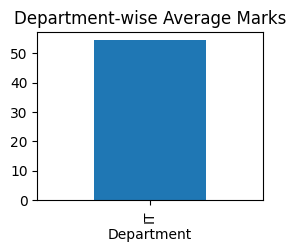

In [40]:
plt.subplot(2,2,1)
dept_perf.plot(kind='bar')
plt.title('Department-wise Average Marks')

Text(0.5, 1.0, 'Gender Distribution')

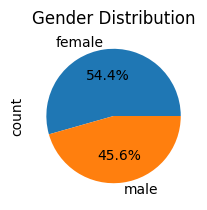

In [42]:
plt.subplot(2,2,2)
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Gender Distribution')

Text(0.5, 1.0, 'Average Marks Distribution')

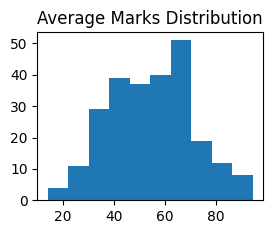

In [44]:
plt.subplot(2,2,3)
plt.hist(data['Average'], bins=10)
plt.title('Average Marks Distribution')


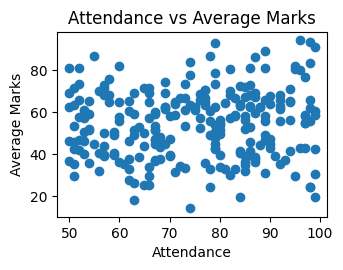

In [45]:
plt.subplot(2,2,4)
plt.scatter(data['Attendance'], data['Average'])
plt.title('Attendance vs Average Marks')
plt.xlabel('Attendance')
plt.ylabel('Average Marks')

plt.tight_layout()
plt.show()

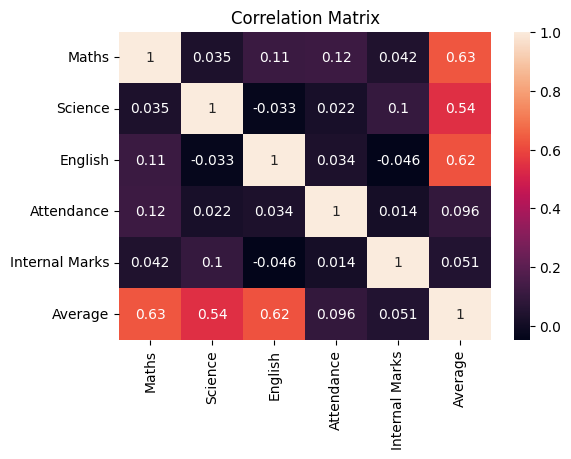

In [47]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Maths','Science','English','Attendance','Internal Marks','Average']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [48]:
print("\n--- Insights ---")
print("1. Students with higher attendance tend to score better.")
print("2. Internal marks show positive relation with final performance.")
print("3. Department-wise variation exists in performance.")
print("4. Few students fall into fail category and need attention.")


--- Insights ---
1. Students with higher attendance tend to score better.
2. Internal marks show positive relation with final performance.
3. Department-wise variation exists in performance.
4. Few students fall into fail category and need attention.
